# 03b -- Can we identify the chromosome vs pole share of interpolar separation?

## Question

During early prometaphase, centrosome poles separate while chromosomes
gather toward the metaphase plate.  Two classes of force act on each
pole:

- **pole-pole (pp):** effective forces that depend on the distance
  between the two poles (absorbing cortical pulling, motor sliding,
  elastic restoring, etc.)
- **chromosome-pole (cp):** forces from chromosomes acting on each pole
  (kinetochore motors, polar ejection, etc.)

We fit pairwise radial interaction kernels $f_{pp}(r)$ and $f_{cp}(r)$
to predict pole velocity at each frame, using B-spline basis expansions
and ridge regression (same machinery as notebook 03).

The broader question behind notebooks `02` and `03` is simpler:
**is there any pole-motion signature tied to chromosome geometry at
all, or are other forces on the poles totally dominant?**

This notebook's answer is:

- **yes**, there is a small pole-motion component statistically aligned
  with chromosome geometry
- but that signature looks like a modest common-mode / pole-midpoint
  bias, not a clean identification of the chromosome share of
  interpolar separation
- and by itself it does **not** orient causality, because poles also
  shape chromosome geometry

The more specific question here is therefore:
**what fraction of interpolar separation is driven by chromosome
forces vs pole-pole forces, given that a small chromosome signature
does seem to be present?**

## Setup

Let $\mathbf{y}_p(t)$ be the position of pole $p \in \{1,2\}$,
$\mathbf{x}_j(t)$ the position of chromosome $j$, and define:

- pole midpoint: $\bar{\mathbf{y}} = \tfrac{1}{2}(\mathbf{y}_1 + \mathbf{y}_2)$
- chromosome COM: $\bar{\mathbf{x}} = \tfrac{1}{N}\sum_j \mathbf{x}_j$
- spindle axis: $\hat{\mathbf{u}}_{pp} = (\mathbf{y}_2 - \mathbf{y}_1)/\|\mathbf{y}_2 - \mathbf{y}_1\|$
- chrom-pole direction: $\hat{\mathbf{u}}_{cp} = (\bar{\mathbf{x}} - \bar{\mathbf{y}})/\|\bar{\mathbf{x}} - \bar{\mathbf{y}}\|$

We decompose full 3D pole velocity into two scalar observables:

1. **Pole COM drift** along $\hat{\mathbf{u}}_{cp}$: does the spindle
   midpoint translate toward/away from the chromosome cloud?
2. **Spindle separation rate** along $\hat{\mathbf{u}}_{pp}$: how fast
   are the poles moving apart along the spindle axis?

These are the observables that matter for Alex's question.  The full 3D
pole velocity mixes both of these with transverse drift/wobble, so its
apparent pp/cp split is not directly interpretable as a force partition.

## Key structural point

The pp interaction term is antisymmetric between the two poles: it
pushes pole 1 toward pole 2 and pole 2 toward pole 1 (or vice versa)
with equal magnitude.  This means **the pp term cannot move the pole
midpoint** -- it can only change the separation.  So any pole-COM drift
signal necessarily lives in the cp block by construction, regardless of
the underlying biology.

## Bottom line (details below)

The trajectory regression gives a two-part answer:

1. **Yes**, there is a detectable but small pole-motion signature tied
   to chromosome geometry, most cleanly seen as pole-midpoint drift
   toward the chromosome cloud.
2. **No**, the regression does not identify the pp/cp partition of
   interpolar separation.  The pp-only and cp-only models are nearly
   tied in cross-validation because the full pp and cp separation
   design blocks overlap strongly over early prometaphase.

So the current data argue against "totally dominant external pole
forces with zero chromosome-geometry signature," but they do not tell
us whether chromosomes contribute 10%, 50%, or 90% of spindle
separation, and they do not by themselves prove causal chromosome
back-reaction on poles.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize, minimize_scalar
from scipy.linalg import block_diag

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())

from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import pole_center, trim_trajectory
from chromlearn.model_fitting.basis import BSplineBasis

plt.rcParams["figure.dpi"] = 110

## Configuration

In [2]:
FRAC = 0.4
MIN_FRAMES = 25

R_MIN = 0.3
R_MAX = 15.0
N_BASIS = 6
LAMBDA_RIDGE = 1e-6
LAMBDA_ROUGH = 1.0

COND_CTRL = "rpe18_ctr"
COND_PRC = "rpe18_prc"

## Load trimmed cells

In [3]:
def load_trimmed(condition: str):
    cells = []
    for cell in load_condition(condition):
        try:
            cells.append(
                trim_trajectory(
                    cell,
                    method="neb_ao_frac",
                    frac=FRAC,
                    min_frames=MIN_FRAMES,
                )
            )
        except ValueError:
            pass
    return cells


cells_ctrl = load_trimmed(COND_CTRL)
cells_prc = load_trimmed(COND_PRC)

print(f"{COND_CTRL}: {len(cells_ctrl)} cells")
print([cell.cell_id for cell in cells_ctrl])
print()
print(f"{COND_PRC}: {len(cells_prc)} cells")
print([cell.cell_id for cell in cells_prc])

rpe18_ctr: 12 cells
['rpe18_ctr_006', 'rpe18_ctr_032', 'rpe18_ctr_034', 'rpe18_ctr_035', 'rpe18_ctr_043', 'rpe18_ctr_049', 'rpe18_ctr_500', 'rpe18_ctr_501', 'rpe18_ctr_502', 'rpe18_ctr_505', 'rpe18_ctr_506', 'rpe18_ctr_509']

rpe18_prc: 14 cells
['rpe18_prc_025', 'rpe18_prc_033', 'rpe18_prc_706', 'rpe18_prc_709', 'rpe18_prc_712', 'rpe18_prc_717', 'rpe18_prc_718', 'rpe18_prc_718c', 'rpe18_prc_726', 'rpe18_prc_726c', 'rpe18_prc_728', 'rpe18_prc_734', 'rpe18_prc_735', 'rpe18_prc_736']


## Lab-frame projection analysis

Before fitting interaction kernels, we reproduce the model-free
projection test from notebook 02c.  For each cell and frame we project
the pole-midpoint velocity and chromosome-COM velocity onto
$\hat{\mathbf{u}}_{cp}$ and $\hat{\mathbf{u}}_{pp}$, then report
per-cell means (the appropriate unit of replication, since consecutive
frames are autocorrelated).

We compare:

- control cells in 3D
- control cells in 2D $(x,y)$ only, matching the MATLAB analysis
- PRC1-depleted cells in 3D

The key finding is that `cp_rel < 0` (chromosomes close on the pole
midpoint) is robust across conditions, but which lab-frame term
(`cp_pole` vs `cp_chrom`) carries the signal differs between control
and PRC -- so mixing conditions explains why earlier analyses seemed
to give opposite results.

Important caveat: `cp_pole > 0` is only a **lab-frame association**
between pole-midpoint velocity and chromosome-geometry offset.  It is
not, by itself, causal evidence that chromosomes push the poles.
Common-mode spindle translation or reorientation correlated with
chromosome geometry could produce the same sign.

In [4]:
PROJ_KEYS = ["cp_pole", "cp_chrom", "cp_rel", "pp_pole", "pp_chrom", "pp_rel"]


def chrom_com_over_time(chromosomes: np.ndarray) -> np.ndarray:
    summed = np.nansum(chromosomes, axis=2)
    counts = np.sum(~np.isnan(chromosomes), axis=2)
    return np.divide(
        summed,
        counts,
        out=np.full_like(summed, np.nan),
        where=counts > 0,
    )


def chrom_com_at_frame(chromosomes_t: np.ndarray) -> np.ndarray:
    summed = np.nansum(chromosomes_t, axis=0)
    counts = np.sum(~np.isnan(chromosomes_t), axis=0)
    return np.divide(
        summed,
        counts,
        out=np.full_like(summed, np.nan),
        where=counts > 0,
    )


def projection_summary(cells, dims=slice(None)):
    cell_means = {key: [] for key in PROJ_KEYS}

    for cell in cells:
        pole_com = pole_center(cell)[:, dims]
        chrom_com = chrom_com_over_time(cell.chromosomes)[:, dims]
        p1 = cell.centrioles[:, dims, 0]
        p2 = cell.centrioles[:, dims, 1]
        T = pole_com.shape[0]

        u_cp = chrom_com - pole_com
        u_pp = p2 - p1
        v_pole = pole_com[1:] - pole_com[:-1]
        v_chrom = chrom_com[1:] - chrom_com[:-1]
        valid = np.ones(T - 1, dtype=bool)
        valid &= ~np.any(np.isnan(v_pole), axis=1)
        valid &= ~np.any(np.isnan(v_chrom), axis=1)
        valid &= ~np.any(np.isnan(chrom_com[: T - 1]), axis=1)

        v_pole = v_pole[valid]
        v_chrom = v_chrom[valid]
        u_cp = u_cp[: T - 1][valid]
        u_pp = u_pp[: T - 1][valid]

        cp_norm = np.linalg.norm(u_cp, axis=1, keepdims=True)
        pp_norm = np.linalg.norm(u_pp, axis=1, keepdims=True)
        u_cp = np.where(cp_norm > 1e-6, u_cp / cp_norm, 0.0)
        u_pp = np.where(pp_norm > 1e-6, u_pp / pp_norm, 0.0)
        v_rel = v_chrom - v_pole

        dot = lambda a, b: np.sum(a * b, axis=1)
        projections = {
            "cp_pole": dot(v_pole, u_cp),
            "cp_chrom": dot(v_chrom, u_cp),
            "cp_rel": dot(v_rel, u_cp),
            "pp_pole": dot(v_pole, u_pp),
            "pp_chrom": dot(v_chrom, u_pp),
            "pp_rel": dot(v_rel, u_pp),
        }
        for key in PROJ_KEYS:
            cell_means[key].append(float(np.mean(projections[key])))

    return {
        key: {
            "mean": float(np.mean(values)),
            "se": float(np.std(values, ddof=1) / np.sqrt(len(values))),
            "values": np.array(values),
        }
        for key, values in cell_means.items()
    }


proj_ctrl_3d = projection_summary(cells_ctrl, slice(None))
proj_ctrl_2d = projection_summary(cells_ctrl, slice(0, 2))
proj_prc_3d = projection_summary(cells_prc, slice(None))


def print_projection_block(title, summary):
    print(title)
    for key in PROJ_KEYS:
        stats = summary[key]
        print(f"  {key:<10s} mean={stats['mean']:+.5f}  se={stats['se']:.5f}")
    print()


print_projection_block("Control, 3D", proj_ctrl_3d)
print_projection_block("Control, 2D", proj_ctrl_2d)
print_projection_block("PRC, 3D", proj_prc_3d)

Control, 3D
  cp_pole    mean=+0.01326  se=0.00303
  cp_chrom   mean=+0.00282  se=0.00415
  cp_rel     mean=-0.01044  se=0.00209
  pp_pole    mean=-0.00384  se=0.00264
  pp_chrom   mean=-0.00180  se=0.00310
  pp_rel     mean=+0.00204  se=0.00293

Control, 2D
  cp_pole    mean=+0.01332  se=0.00338
  cp_chrom   mean=+0.00412  se=0.00399
  cp_rel     mean=-0.00921  se=0.00181
  pp_pole    mean=-0.00682  se=0.00419
  pp_chrom   mean=-0.00724  se=0.00417
  pp_rel     mean=-0.00041  se=0.00289

PRC, 3D
  cp_pole    mean=+0.00308  se=0.00355
  cp_chrom   mean=-0.00872  se=0.00326
  cp_rel     mean=-0.01180  se=0.00251
  pp_pole    mean=-0.00697  se=0.00492
  pp_chrom   mean=-0.00667  se=0.00417
  pp_rel     mean=+0.00030  se=0.00397



## Why `cp_chrom` can be small without contradicting chromosome gathering

`cp_chrom` is a **lab-frame chromosome-COM drift** statistic.  It is
not the same thing as chromosome congression.  If chromosomes on both
spindle halves move inward together, the cloud COM can stay nearly
fixed while the cloud contracts strongly in spindle coordinates.

To separate these, we track two normalized spindle-frame quantities in
control cells:

1. `|chrom COM axial offset| / half spindle length`
2. `mean_j |chrom axial position_j| / half spindle length`

Both should decrease if chromosomes gather toward the metaphase plate
relative to the spindle, even if the lab-frame COM drift is small.

In [5]:
def spindle_frame_congression_summary(cells):
    com_norm_start = []
    com_norm_end = []
    width_norm_start = []
    width_norm_end = []

    for cell in cells:
        p1 = cell.centrioles[:, :, 0]
        p2 = cell.centrioles[:, :, 1]
        center = 0.5 * (p1 + p2)
        axis = p2 - p1
        half_len = 0.5 * np.linalg.norm(axis, axis=1)
        axis_unit = axis / np.linalg.norm(axis, axis=1, keepdims=True)

        delta = cell.chromosomes - center[:, :, np.newaxis]
        axial = np.einsum("tdi,td->ti", delta, axis_unit)
        com_axial = np.nanmean(axial, axis=1)

        com_norm = np.abs(com_axial) / half_len
        width_norm = np.nanmean(np.abs(axial) / half_len[:, np.newaxis], axis=1)

        com_norm_start.append(float(com_norm[0]))
        com_norm_end.append(float(com_norm[-1]))
        width_norm_start.append(float(width_norm[0]))
        width_norm_end.append(float(width_norm[-1]))

    return {
        "com_norm_start": np.array(com_norm_start),
        "com_norm_end": np.array(com_norm_end),
        "width_norm_start": np.array(width_norm_start),
        "width_norm_end": np.array(width_norm_end),
    }


congression_ctrl = spindle_frame_congression_summary(cells_ctrl)
print("Control, spindle-frame congression summary")
print(
    "  |chrom COM axial| / half spindle: "
    f"{congression_ctrl['com_norm_start'].mean():.3f} -> "
    f"{congression_ctrl['com_norm_end'].mean():.3f}"
)
print(
    "  mean |chrom axial| / half spindle: "
    f"{congression_ctrl['width_norm_start'].mean():.3f} -> "
    f"{congression_ctrl['width_norm_end'].mean():.3f}"
)

Control, spindle-frame congression summary
  |chrom COM axial| / half spindle: 0.248 -> 0.051
  mean |chrom axial| / half spindle: 0.600 -> 0.232


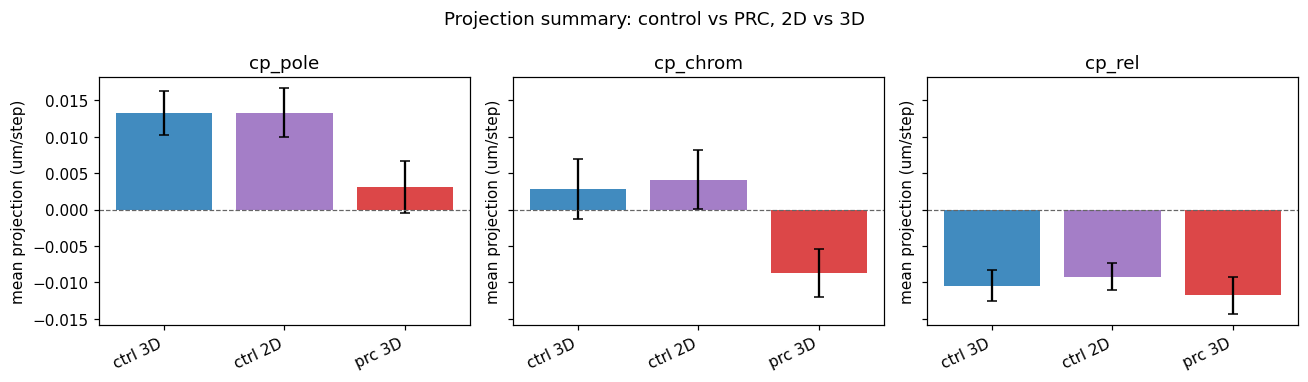

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
labels = ["cp_pole", "cp_chrom", "cp_rel"]
x = np.arange(len(labels))
width = 0.25

series = [
    ("ctrl 3D", "C0", proj_ctrl_3d),
    ("ctrl 2D", "C4", proj_ctrl_2d),
    ("prc 3D", "C3", proj_prc_3d),
]

for ax, key_group in zip(
    axes,
    [["cp_pole"], ["cp_chrom"], ["cp_rel"]],
):
    label = key_group[0]
    for idx, (name, color, summary) in enumerate(series):
        value = summary[label]["mean"]
        err = summary[label]["se"]
        ax.bar(idx, value, yerr=err, color=color, alpha=0.85, capsize=3)
    ax.axhline(0, color="0.4", linestyle="--", linewidth=0.8)
    ax.set_xticks(range(len(series)))
    ax.set_xticklabels([name for name, _, _ in series], rotation=25, ha="right")
    ax.set_title(label)
    ax.set_ylabel("mean projection (um/step)")

fig.suptitle("Projection summary: control vs PRC, 2D vs 3D")
fig.tight_layout()
plt.show()

## Interaction kernel regression

We fit the same pairwise radial kernels as notebook 03: B-spline basis
expansions for $f_{pp}(r)$ and $f_{cp}(r)$, with light ridge and
roughness regularization.  Each pole at each frame contributes one
3D velocity observation.

From the same feature matrices we extract two scalar observables:

1. **Pole COM drift** along $\hat{\mathbf{u}}_{cp}$: average of the
   two poles' velocities projected onto the chrom-pole direction.
2. **Spindle separation rate** along $\hat{\mathbf{u}}_{pp}$:
   difference of the two poles' velocities projected onto the spindle
   axis, i.e. $\dot{r}_{pp}$.

For each observable we fit three models and compare with
leave-one-cell-out cross-validation:

- **pp only** (0% cp by construction)
- **cp only** (100% cp by construction)
- **full** (pp + cp, optimizer chooses the partition)

In [7]:
basis_pp = BSplineBasis(R_MIN, R_MAX, N_BASIS)
basis_cp = BSplineBasis(R_MIN, R_MAX, N_BASIS)
R_pp = basis_pp.roughness_matrix()
R_cp = basis_cp.roughness_matrix()
R_full = block_diag(R_pp, R_cp)


def ridge_fit(G, V, R):
    n = G.shape[1]
    theta = np.linalg.solve(
        G.T @ G + LAMBDA_RIDGE * np.eye(n) + LAMBDA_ROUGH * R,
        G.T @ V,
    )
    residuals = V - G @ theta
    return theta, residuals


def build_pole_feature_rows(cells):
    cell_pole_rows = []
    cell_sep_rows = []
    cell_com_rows = []
    all_G = []
    all_V = []

    for cell in cells:
        pole_rows = []
        sep_rows = []
        com_rows = []
        T = cell.centrioles.shape[0]

        for t in range(T - 1):
            poles_cur = cell.centrioles[t].T
            poles_next = cell.centrioles[t + 1].T
            chroms = cell.chromosomes[t].T

            pole_com_cur = 0.5 * (poles_cur[0] + poles_cur[1])
            chrom_com_cur = chrom_com_at_frame(chroms)
            if np.any(np.isnan(chrom_com_cur)):
                continue

            axis = poles_cur[1] - poles_cur[0]
            r_pp = np.linalg.norm(axis)
            if r_pp < 1e-12:
                continue
            u_pp = axis / r_pp

            cp_vec = chrom_com_cur - pole_com_cur
            cp_norm = np.linalg.norm(cp_vec)
            if cp_norm < 1e-12 or np.isnan(cp_norm):
                continue
            u_cp = cp_vec / cp_norm

            gpp = []
            gcp = []
            vobs = []
            mean_cp_dist = []

            for p in range(2):
                pole_vel = (poles_next[p] - poles_cur[p]) / cell.dt
                other = 1 - p

                delta_pp = poles_cur[other] - poles_cur[p]
                r_pp_val = np.linalg.norm(delta_pp)
                dir_pp = delta_pp / r_pp_val
                phi_pp = basis_pp.evaluate(np.array([r_pp_val]))[0]
                g_pp = dir_pp[:, np.newaxis] * phi_pp[np.newaxis, :]

                g_cp = np.zeros((3, N_BASIS))
                valid_chroms = ~np.any(np.isnan(chroms), axis=1)
                if valid_chroms.any():
                    chroms_valid = chroms[valid_chroms]
                    delta_cp = chroms_valid - poles_cur[p]
                    dist_cp = np.linalg.norm(delta_cp, axis=1)
                    pair_ok = dist_cp > 1e-12
                    mean_cp_dist.append(float(np.mean(dist_cp[pair_ok])))
                    if pair_ok.any():
                        dir_cp = delta_cp[pair_ok] / dist_cp[pair_ok, np.newaxis]
                        phi_cp = basis_cp.evaluate(dist_cp[pair_ok])
                        g_cp = np.einsum("id,ib->db", dir_cp, phi_cp)

                gpp.append(g_pp)
                gcp.append(g_cp)
                vobs.append(pole_vel)
                all_G.append(np.hstack([g_pp, g_cp]))
                all_V.append(pole_vel)

            gpp = np.stack(gpp)
            gcp = np.stack(gcp)
            vobs = np.stack(vobs)

            for p in range(2):
                pole_rows.append({"Gpp": gpp[p], "Gcp": gcp[p], "v": vobs[p]})

            com_rows.append(
                {
                    "gpp": np.einsum("d,db->b", u_cp, 0.5 * (gpp[0] + gpp[1])),
                    "gcp": np.einsum("d,db->b", u_cp, 0.5 * (gcp[0] + gcp[1])),
                    "y": float(np.dot(u_cp, 0.5 * (vobs[0] + vobs[1]))),
                }
            )

            sep_rows.append(
                {
                    "gpp": np.einsum("d,db->b", u_pp, gpp[1] - gpp[0]),
                    "gcp": np.einsum("d,db->b", u_pp, gcp[1] - gcp[0]),
                    "y": float(np.dot(u_pp, vobs[1] - vobs[0])),
                    "r_pp": float(r_pp),
                    "mean_cp_dist": float(np.mean(mean_cp_dist)),
                    "u_pp": u_pp.copy(),
                    "delta_pp_vecs": (gpp[1] - gpp[0]).copy(),
                    "delta_cp_vecs": (gcp[1] - gcp[0]).copy(),
                }
            )

        cell_pole_rows.append(pole_rows)
        cell_sep_rows.append(sep_rows)
        cell_com_rows.append(com_rows)

    return cell_pole_rows, cell_sep_rows, cell_com_rows, np.vstack(all_G), np.concatenate(all_V)


cell_pole_rows, cell_sep_rows, cell_com_rows, G_3d, V_3d = build_pole_feature_rows(cells_ctrl)

## Full 3D pole-velocity fits

First we reproduce the full 3D regression from notebook 03, including
the magnitude fraction $|F_{cp}|/(|F_{pp}|+|F_{cp}|)$.  This number
is easy to over-interpret: it is only an average magnitude split of
fitted vector components, mixing common translation, separation, and
transverse motion.  It is **not** a force partition for any single
physical observable, and in this model family it partly reflects the
fact that the pp block cannot produce pole-midpoint translation at all.

In [8]:
theta_3d_full, res_3d_full = ridge_fit(G_3d, V_3d, R_full)
theta_3d_pp, res_3d_pp = ridge_fit(G_3d[:, :N_BASIS], V_3d, R_pp)
theta_3d_cp, res_3d_cp = ridge_fit(G_3d[:, N_BASIS:], V_3d, R_cp)

ss_tot_3d = np.sum((V_3d - V_3d.mean()) ** 2)
for label, residuals in [
    ("full", res_3d_full),
    ("pp only", res_3d_pp),
    ("cp only", res_3d_cp),
]:
    r2 = 1 - np.sum(residuals**2) / ss_tot_3d
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"3D {label:<7s}  R2={r2:.4f}  RMSE={rmse:.5f} um/s")

pred_3d_pp = (G_3d[:, :N_BASIS] @ theta_3d_full[:N_BASIS]).reshape(-1, 3)
pred_3d_cp = (G_3d[:, N_BASIS:] @ theta_3d_full[N_BASIS:]).reshape(-1, 3)
mag_3d_pp = np.linalg.norm(pred_3d_pp, axis=1)
mag_3d_cp = np.linalg.norm(pred_3d_cp, axis=1)
frac_cp_3d_mag = np.mean(mag_3d_cp / np.where(mag_3d_pp + mag_3d_cp > 0, mag_3d_pp + mag_3d_cp, 1.0))
delta_r2_3d = (1 - np.sum(res_3d_full**2) / ss_tot_3d) - (1 - np.sum(res_3d_pp**2) / ss_tot_3d)
f2_3d_vs_pp = delta_r2_3d / (1 - (1 - np.sum(res_3d_full**2) / ss_tot_3d))
print(f"Mean cp magnitude fraction in 3D full model: {frac_cp_3d_mag:.3f}")
print(f"Incremental value of adding cp beyond pp in 3D: dR2={delta_r2_3d:.4f}, Cohen f2={f2_3d_vs_pp:.4f}")

3D full     R2=0.0720  RMSE=0.01984 um/s
3D pp only  R2=0.0514  RMSE=0.02006 um/s
3D cp only  R2=0.0422  RMSE=0.02016 um/s
Mean cp magnitude fraction in 3D full model: 0.379
Incremental value of adding cp beyond pp in 3D: dR2=0.0207, Cohen f2=0.0223


## Scalar regression helpers

In [9]:
def stack_scalar_rows(cell_rows):
    G = []
    Y = []
    for rows in cell_rows:
        for row in rows:
            G.append(np.concatenate([row["gpp"], row["gcp"]]))
            Y.append(row["y"])
    return np.vstack(G), np.array(Y)


def stack_pole_rows(cell_rows):
    G = []
    V = []
    for rows in cell_rows:
        for row in rows:
            G.append(np.hstack([row["Gpp"], row["Gcp"]]))
            V.append(row["v"])
    return np.vstack(G), np.concatenate(V)


def fit_scalar_models(cell_rows):
    G, Y = stack_scalar_rows(cell_rows)
    theta_full, res_full = ridge_fit(G, Y, R_full)
    theta_pp, res_pp = ridge_fit(G[:, :N_BASIS], Y, R_pp)
    theta_cp, res_cp = ridge_fit(G[:, N_BASIS:], Y, R_cp)
    ss_tot = np.sum((Y - Y.mean()) ** 2)

    summary = {}
    for label, theta, residuals in [
        ("full", theta_full, res_full),
        ("pp only", theta_pp, res_pp),
        ("cp only", theta_cp, res_cp),
    ]:
        summary[label] = {
            "theta": theta,
            "r2": float(1 - np.sum(residuals**2) / ss_tot),
            "rmse": float(np.sqrt(np.mean(residuals**2))),
        }

    pred_pp = G[:, :N_BASIS] @ theta_full[:N_BASIS]
    pred_cp = G[:, N_BASIS:] @ theta_full[N_BASIS:]
    summary["cp_abs_fraction"] = float(
        np.mean(np.abs(pred_cp) / np.where(np.abs(pred_pp) + np.abs(pred_cp) > 0, np.abs(pred_pp) + np.abs(pred_cp), 1.0))
    )
    summary["G"] = G
    summary["Y"] = Y
    return summary


def smooth_abs(x, eps=1e-12):
    return np.sqrt(x * x + eps) - np.sqrt(eps)


def cp_share_exact_from_theta(G, theta):
    pred_pp = G[:, :N_BASIS] @ theta[:N_BASIS]
    pred_cp = G[:, N_BASIS:] @ theta[N_BASIS:]
    return float(
        np.mean(
            np.abs(pred_cp)
            / np.where(
                np.abs(pred_pp) + np.abs(pred_cp) > 0,
                np.abs(pred_pp) + np.abs(pred_cp),
                1.0,
            )
        )
    )


def cp_share_smooth_from_theta(G, theta):
    pred_pp = G[:, :N_BASIS] @ theta[:N_BASIS]
    pred_cp = G[:, N_BASIS:] @ theta[N_BASIS:]
    mag_pp = smooth_abs(pred_pp)
    mag_cp = smooth_abs(pred_cp)
    return float(np.mean(mag_cp / (mag_pp + mag_cp + 1e-12)))


def scalar_objective(theta, G, Y, R):
    residuals = Y - G @ theta
    return float(
        residuals @ residuals
        + LAMBDA_RIDGE * (theta @ theta)
        + LAMBDA_ROUGH * (theta @ R @ theta)
    )


def initial_theta_for_target_share(G, theta_full, target_share):
    theta0 = theta_full.copy()

    def scale_mismatch(scale):
        theta_try = theta0.copy()
        theta_try[N_BASIS:] *= scale
        return (cp_share_smooth_from_theta(G, theta_try) - target_share) ** 2

    result = minimize_scalar(scale_mismatch, bounds=(0.0, 50.0), method="bounded")
    theta0[N_BASIS:] *= result.x
    return theta0


def fit_scalar_model_with_share_target(G, Y, target_share):
    if target_share <= 1e-8:
        theta_pp, _ = ridge_fit(G[:, :N_BASIS], Y, R_pp)
        theta = np.concatenate([theta_pp, np.zeros(N_BASIS)])
        return theta, {"success": True, "method": "pp_only"}

    if target_share >= 1 - 1e-8:
        theta_cp, _ = ridge_fit(G[:, N_BASIS:], Y, R_cp)
        theta = np.concatenate([np.zeros(N_BASIS), theta_cp])
        return theta, {"success": True, "method": "cp_only"}

    theta_full, _ = ridge_fit(G, Y, R_full)
    theta_pp, _ = ridge_fit(G[:, :N_BASIS], Y, R_pp)
    theta_cp, _ = ridge_fit(G[:, N_BASIS:], Y, R_cp)
    theta_pp_only = np.concatenate([theta_pp, np.zeros(N_BASIS)])
    theta_cp_only = np.concatenate([np.zeros(N_BASIS), theta_cp])

    candidate_inits = [
        initial_theta_for_target_share(G, theta_full, target_share),
        (1 - target_share) * theta_pp_only + target_share * theta_cp_only,
        theta_full.copy(),
    ]

    best = None
    best_meta = None

    for theta_init in candidate_inits:
        result = minimize(
            lambda th: scalar_objective(th, G, Y, R_full),
            theta_init,
            method="SLSQP",
            constraints=[
                {
                    "type": "eq",
                    "fun": lambda th, G=G, target_share=target_share: cp_share_smooth_from_theta(G, th)
                    - target_share,
                }
            ],
            options={"ftol": 1e-9, "maxiter": 1000, "disp": False},
        )

        theta_try = result.x
        share_err = abs(cp_share_smooth_from_theta(G, theta_try) - target_share)
        meta = {
            "success": bool(result.success) and share_err < 5e-3,
            "message": result.message,
            "share_err": float(share_err),
        }

        if best is None or scalar_objective(theta_try, G, Y, R_full) < scalar_objective(best, G, Y, R_full):
            best = theta_try
            best_meta = meta

        if meta["success"]:
            return theta_try, meta

    return best, best_meta


def block_reconstruct_r2(target_block, source_block):
    theta, *_ = np.linalg.lstsq(source_block, target_block, rcond=None)
    target_hat = source_block @ theta
    ss = np.sum((target_block - target_block.mean(axis=0)) ** 2)
    return float(1 - np.sum((target_block - target_hat) ** 2) / ss)


def loocv_scalar(cell_rows):
    rmses = {"full": [], "pp only": [], "cp only": []}
    for i in range(len(cell_rows)):
        train = [rows for j, rows in enumerate(cell_rows) if j != i]
        test = [cell_rows[i]]
        G_train, Y_train = stack_scalar_rows(train)
        G_test, Y_test = stack_scalar_rows(test)

        theta_full, _ = ridge_fit(G_train, Y_train, R_full)
        theta_pp, _ = ridge_fit(G_train[:, :N_BASIS], Y_train, R_pp)
        theta_cp, _ = ridge_fit(G_train[:, N_BASIS:], Y_train, R_cp)

        rmses["full"].append(float(np.sqrt(np.mean((Y_test - G_test @ theta_full) ** 2))))
        rmses["pp only"].append(float(np.sqrt(np.mean((Y_test - G_test[:, :N_BASIS] @ theta_pp) ** 2))))
        rmses["cp only"].append(float(np.sqrt(np.mean((Y_test - G_test[:, N_BASIS:] @ theta_cp) ** 2))))
    return {key: np.array(values) for key, values in rmses.items()}


def constrained_share_sweep(cell_rows, target_shares):
    G, Y = stack_scalar_rows(cell_rows)
    train_rows = []
    loocv_rows = []

    for target in target_shares:
        theta, meta = fit_scalar_model_with_share_target(G, Y, target)
        train_rows.append(
            {
                "target": float(target),
                "actual_share": cp_share_exact_from_theta(G, theta),
                "rmse": float(np.sqrt(np.mean((Y - G @ theta) ** 2))),
                "success": bool(meta["success"]),
            }
        )

        fold_rmses = []
        fold_shares = []
        for i in range(len(cell_rows)):
            train = [rows for j, rows in enumerate(cell_rows) if j != i]
            test = [cell_rows[i]]
            G_train, Y_train = stack_scalar_rows(train)
            G_test, Y_test = stack_scalar_rows(test)
            theta_fold, meta_fold = fit_scalar_model_with_share_target(G_train, Y_train, target)
            fold_rmses.append(float(np.sqrt(np.mean((Y_test - G_test @ theta_fold) ** 2))))
            fold_shares.append(cp_share_exact_from_theta(G_train, theta_fold))

        loocv_rows.append(
            {
                "target": float(target),
                "mean_actual_share": float(np.mean(fold_shares)),
                "rmse_mean": float(np.mean(fold_rmses)),
                "rmse_se": float(np.std(fold_rmses, ddof=1) / np.sqrt(len(fold_rmses))),
            }
        )

    return train_rows, loocv_rows


def loocv_3d(cell_rows):
    rmses = {"full": [], "pp only": [], "cp only": []}
    for i in range(len(cell_rows)):
        train = [rows for j, rows in enumerate(cell_rows) if j != i]
        test = [cell_rows[i]]
        G_train, V_train = stack_pole_rows(train)
        G_test, V_test = stack_pole_rows(test)

        theta_full, _ = ridge_fit(G_train, V_train, R_full)
        theta_pp, _ = ridge_fit(G_train[:, :N_BASIS], V_train, R_pp)
        theta_cp, _ = ridge_fit(G_train[:, N_BASIS:], V_train, R_cp)

        rmses["full"].append(float(np.sqrt(np.mean((V_test - G_test @ theta_full) ** 2))))
        rmses["pp only"].append(float(np.sqrt(np.mean((V_test - G_test[:, :N_BASIS] @ theta_pp) ** 2))))
        rmses["cp only"].append(float(np.sqrt(np.mean((V_test - G_test[:, N_BASIS:] @ theta_cp) ** 2))))
    return {key: np.array(values) for key, values in rmses.items()}

## Observable 1: pole-COM drift along the chrom-pole direction

Does the spindle midpoint translate toward the chromosome cloud?

Because the pp term is antisymmetric (equal and opposite on the two
poles), it cannot produce any net translation of the pole midpoint.
The pp design-matrix entries for this observable are exactly zero.
So any pole-COM drift signal is carried entirely by the cp block --
this is a structural property of the model, not a biological finding.

**How to read the results:** If LOOCV RMSE for cp-only is close to the
null (pp-only, which predicts zero everywhere), then the cp block does
not meaningfully predict COM drift out of sample either -- the effect
is small, noisy, and still not causal proof of chromosome-on-pole
force.  It could equally reflect an omitted common-mode field that is
correlated with chromosome geometry.

In [10]:
fit_com = fit_scalar_models(cell_com_rows)
cv_com = loocv_scalar(cell_com_rows)
max_abs_pp_com = float(np.max(np.abs(fit_com["G"][:, :N_BASIS])))

print("COM drift along chrom-pole axis")
print(f"  max |pp design entry| for COM observable: {max_abs_pp_com:.3e}")
for label in ["pp only", "cp only", "full"]:
    print(
        f"  {label:<7s}  train_R2={fit_com[label]['r2']:.4f}  "
        f"train_RMSE={fit_com[label]['rmse']:.5f}  "
        f"LOOCV_RMSE={cv_com[label].mean():.5f}"
    )
print(f"  full-model cp abs fraction: {fit_com['cp_abs_fraction']:.3f}")

COM drift along chrom-pole axis
  max |pp design entry| for COM observable: 0.000e+00
  pp only  train_R2=-0.0505  train_RMSE=0.01259  LOOCV_RMSE=0.01186
  cp only  train_R2=-0.0048  train_RMSE=0.01231  LOOCV_RMSE=0.01191
  full     train_R2=-0.0048  train_RMSE=0.01231  LOOCV_RMSE=0.01191
  full-model cp abs fraction: 1.000


## Observable 2: spindle separation rate along the pole-pole axis

How fast are the poles moving apart?  This is the observable closest to
the biological question about interpolar forces.

The three models serve as bookends:

- **pp only** = a constrained refit where 0% of separation comes from
  chromosomes (the cp kernel is absent, not zeroed out)
- **cp only** = a constrained refit where 100% of separation comes
  from chromosomes
- **full** = the optimizer freely allocates between pp and cp

**How to read the results:** If pp-only and cp-only have nearly the
same LOOCV RMSE, then the data cannot distinguish 0% cp from 100% cp.
That would mean the force partition is non-identifiable from these
kinematics alone.

In [11]:
fit_sep = fit_scalar_models(cell_sep_rows)
cv_sep = loocv_scalar(cell_sep_rows)

print("Spindle separation rate")
for label in ["pp only", "cp only", "full"]:
    print(
        f"  {label:<7s}  train_R2={fit_sep[label]['r2']:.4f}  "
        f"train_RMSE={fit_sep[label]['rmse']:.5f}  "
        f"LOOCV_RMSE={cv_sep[label].mean():.5f}"
    )
print(f"  full-model cp abs fraction: {fit_sep['cp_abs_fraction']:.3f}")

Spindle separation rate
  pp only  train_R2=0.0590  train_RMSE=0.02057  LOOCV_RMSE=0.02022
  cp only  train_R2=0.0971  train_RMSE=0.02015  LOOCV_RMSE=0.02036
  full     train_R2=0.1673  train_RMSE=0.01935  LOOCV_RMSE=0.01981
  full-model cp abs fraction: 0.448


In [12]:
sep_rates = fit_sep["Y"]
print("Observed separation-rate scale in the trimmed control data")
print(f"  mean dr/dt       = {np.mean(sep_rates):.5f} um/s")
print(f"  mean |dr/dt|     = {np.mean(np.abs(sep_rates)):.5f} um/s")
print(f"  median |dr/dt|   = {np.median(np.abs(sep_rates)):.5f} um/s")
print(f"  95th pct dr/dt   = {np.percentile(sep_rates, 95):.5f} um/s")

Observed separation-rate scale in the trimmed control data
  mean dr/dt       = 0.01533 um/s
  mean |dr/dt|     = 0.02083 um/s
  median |dr/dt|   = 0.01812 um/s
  95th pct dr/dt   = 0.04648 um/s


These rates are useful context for the back-of-the-envelope physics
argument in `03` Part C.  They are consistent with the measured spindle
elongation rate of $\sim$0.025 um/s reported in Alex's draft (Result 2),
which we now use in NB03 Part C in place of the earlier mis-quoted
0.5-1 um/s.  The corrected NB03 framing compares the net chromosome
force ($\sim$5 pN) to the dominant ipMT forces ($\sim$10$^2$ pN), not
to the spindle's own velocity, matching Wenzheng's force-balance
argument in Result 2.

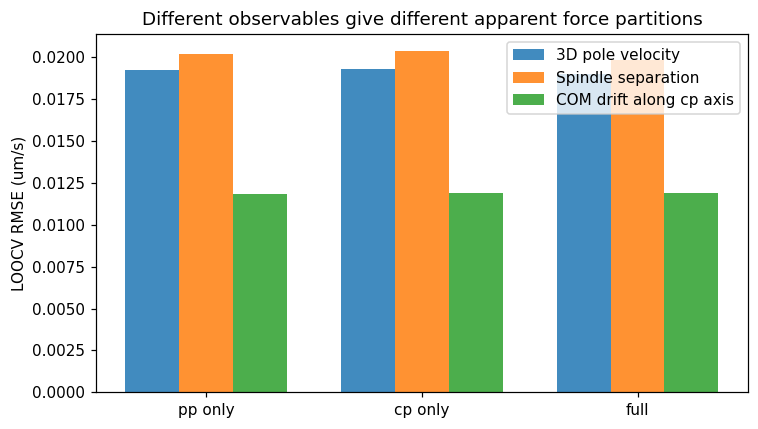

In [13]:
cv_3d = loocv_3d(cell_pole_rows)

labels = ["pp only", "cp only", "full"]
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    x - width,
    [cv_3d[label].mean() for label in labels],
    width,
    label="3D pole velocity",
    color="C0",
    alpha=0.85,
)
ax.bar(
    x,
    [cv_sep[label].mean() for label in labels],
    width,
    label="Spindle separation",
    color="C1",
    alpha=0.85,
)
ax.bar(
    x + width,
    [cv_com[label].mean() for label in labels],
    width,
    label="COM drift along cp axis",
    color="C2",
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("LOOCV RMSE (um/s)")
ax.set_title("Different observables give different apparent force partitions")
ax.legend()
fig.tight_layout()
plt.show()

## The two models predict nearly the same separation

The LOOCV numbers above show pp-only and cp-only are nearly tied, but
a scatter plot makes the non-identifiability visceral: we plot the
predicted separation rate from the pp-only model vs the cp-only model
across all observations.  If the two are interchangeable, the points
should cluster tightly around the diagonal.

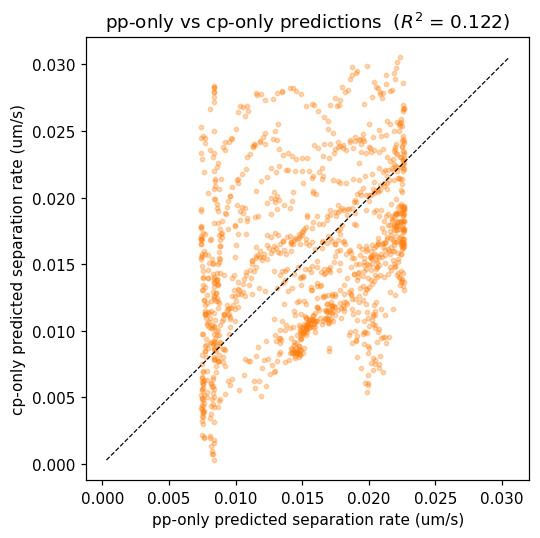

In [14]:
pred_sep_pp_only = fit_sep["G"][:, :N_BASIS] @ fit_sep["pp only"]["theta"]
pred_sep_cp_only = fit_sep["G"][:, N_BASIS:] @ fit_sep["cp only"]["theta"]
r2_pred = np.corrcoef(pred_sep_pp_only, pred_sep_cp_only)[0, 1] ** 2

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pred_sep_pp_only, pred_sep_cp_only, s=8, alpha=0.3, color="C1")
lims = [min(pred_sep_pp_only.min(), pred_sep_cp_only.min()),
        max(pred_sep_pp_only.max(), pred_sep_cp_only.max())]
ax.plot(lims, lims, "k--", linewidth=0.8)
ax.set_xlabel("pp-only predicted separation rate (um/s)")
ax.set_ylabel("cp-only predicted separation rate (um/s)")
ax.set_title(f"pp-only vs cp-only predictions  ($R^2$ = {r2_pred:.3f})")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

## Why the partition is non-identifiable: overlap of the full design blocks

The reason pp-only and cp-only are nearly tied is that chromosome-pole
geometry tracks spindle stage very tightly during early prometaphase.
As the spindle opens, the full chromosome-geometry block seen by the
regression also changes in a highly structured way.

We quantify this with:

- the correlation between pole-pole distance and mean chromosome-pole
  distance across all (cell, frame) observations as an intuitive
  distance-level summary
- the angular alignment between the **actual chromosome-induced
  separation vectors** and the spindle axis
- the $R^2$ of reconstructing each **full design block** from the
  other via ordinary least squares, both for spindle separation and for
  the original 3D pole-velocity fit

This is **not** just a distance correlation test.  For spindle
separation, each `cp` row is already the chromosome block projected
onto the spindle axis, `u_pp · (gcp_2 - gcp_1)`, so directional
information is built into the block.  If chromosome directions were
unrelated to the spindle axis, these cross-block $R^2$ values would
stay low even if raw distances were correlated.

The new angle diagnostic makes that directional point visual: for each
timepoint and each cp basis shell, we look at the 3D vector
`delta_cp_vec = gcp_2 - gcp_1` before projection and measure its angle
to `u_pp`.  If these angles cluster near `0°`, then the chromosome
block is not just stage-locked in distance; it is also already mostly
pointing along the same axis as the pp separation mode.

**How to read the results:** High pp-from-cp or cp-from-pp $R^2$
means the two blocks share a large stage-locked subspace.  The overlap
need not be perfectly symmetric to make the force partition poorly
identifiable.

In [15]:
sep_G = fit_sep["G"]
sep_rows_flat = [row for rows in cell_sep_rows for row in rows]
pp_dist = np.array([row["r_pp"] for row in sep_rows_flat])
cp_dist = np.array([row["mean_cp_dist"] for row in sep_rows_flat])

sep_pp_block = sep_G[:, :N_BASIS]
sep_cp_block = sep_G[:, N_BASIS:]

r2_sep_pp_from_cp = block_reconstruct_r2(sep_pp_block, sep_cp_block)
r2_sep_cp_from_pp = block_reconstruct_r2(sep_cp_block, sep_pp_block)

block_3d_pp = G_3d[:, :N_BASIS]
block_3d_cp = G_3d[:, N_BASIS:]
r2_3d_pp_from_cp = block_reconstruct_r2(block_3d_pp, block_3d_cp)
r2_3d_cp_from_pp = block_reconstruct_r2(block_3d_cp, block_3d_pp)

cp_sep_cosines = []
cp_sep_axis_angles_deg = []
cp_sep_parallel_fractions = []

for row in sep_rows_flat:
    u_pp = row["u_pp"]
    for b in range(N_BASIS):
        vec = row["delta_cp_vecs"][:, b]
        norm = np.linalg.norm(vec)
        if norm < 1e-10:
            continue
        cosine = float(np.dot(u_pp, vec) / norm)
        cosine = np.clip(cosine, -1.0, 1.0)
        cp_sep_cosines.append(cosine)
        cp_sep_axis_angles_deg.append(np.degrees(np.arccos(abs(cosine))))
        parallel = abs(np.dot(u_pp, vec))
        perp = np.linalg.norm(vec - np.dot(u_pp, vec) * u_pp)
        cp_sep_parallel_fractions.append(parallel / (parallel + perp))

cp_sep_cosines = np.array(cp_sep_cosines)
cp_sep_axis_angles_deg = np.array(cp_sep_axis_angles_deg)
cp_sep_parallel_fractions = np.array(cp_sep_parallel_fractions)

print(f"corr(pole-pole distance, mean cp distance) = {np.corrcoef(pp_dist, cp_dist)[0, 1]:.3f}")
print(f"cp separation-vector axis alignment: mean |cos(theta)| = {np.mean(np.abs(cp_sep_cosines)):.3f}")
print(f"cp separation-vector axis alignment: median axis-angle = {np.median(cp_sep_axis_angles_deg):.2f} deg")
print(f"cp separation-vector axis alignment: pct with |cos(theta)| > 0.8 = {np.mean(np.abs(cp_sep_cosines) > 0.8):.3f}")
print(f"Separation pp block reconstructed from cp block: R2 = {r2_sep_pp_from_cp:.3f}")
print(f"Separation cp block reconstructed from pp block: R2 = {r2_sep_cp_from_pp:.3f}")
print(f"3D pp block reconstructed from cp block: R2 = {r2_3d_pp_from_cp:.3f}")
print(f"3D cp block reconstructed from pp block: R2 = {r2_3d_cp_from_pp:.3f}")

corr(pole-pole distance, mean cp distance) = 0.920
cp separation-vector axis alignment: mean |cos(theta)| = 0.910
cp separation-vector axis alignment: median axis-angle = 11.95 deg
cp separation-vector axis alignment: pct with |cos(theta)| > 0.8 = 0.839
Separation pp block reconstructed from cp block: R2 = 0.691
Separation cp block reconstructed from pp block: R2 = 0.903
3D pp block reconstructed from cp block: R2 = 0.674
3D cp block reconstructed from pp block: R2 = 0.899


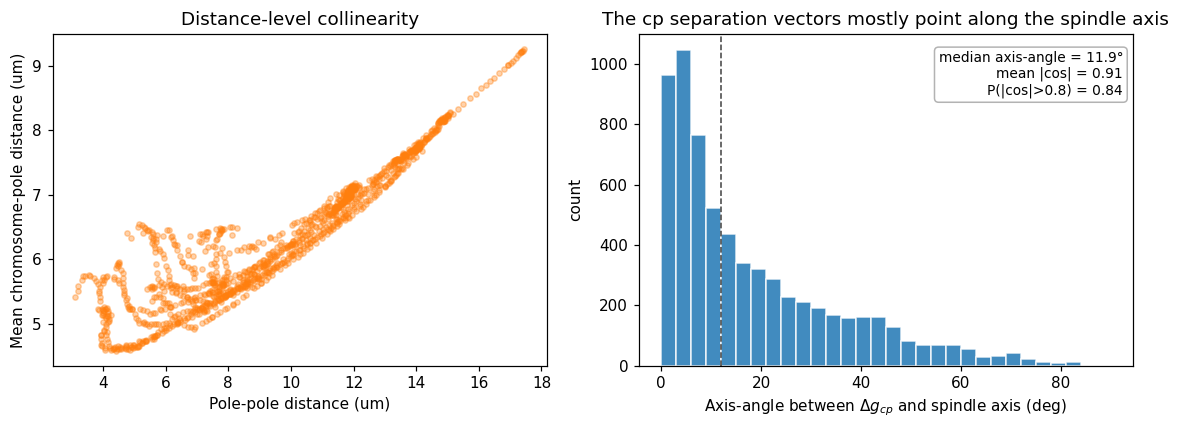

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

axes[0].scatter(pp_dist, cp_dist, s=12, alpha=0.35, color="C1")
axes[0].set_xlabel("Pole-pole distance (um)")
axes[0].set_ylabel("Mean chromosome-pole distance (um)")
axes[0].set_title("Distance-level collinearity")

bins = np.linspace(0, 90, 31)
axes[1].hist(cp_sep_axis_angles_deg, bins=bins, color="C0", alpha=0.85, edgecolor="white")
axes[1].axvline(np.median(cp_sep_axis_angles_deg), color="0.25", linestyle="--", linewidth=1.0)
axes[1].text(
    0.98,
    0.95,
    f"median axis-angle = {np.median(cp_sep_axis_angles_deg):.1f}°\n"
    f"mean |cos| = {np.mean(np.abs(cp_sep_cosines)):.2f}\n"
    f"P(|cos|>0.8) = {np.mean(np.abs(cp_sep_cosines) > 0.8):.2f}",
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7"),
)
axes[1].set_xlabel(r"Axis-angle between $\Delta g_{cp}$ and spindle axis (deg)")
axes[1].set_ylabel("count")
axes[1].set_title("The cp separation vectors mostly point along the spindle axis")

fig.tight_layout()
plt.show()

## Constrained-share refit sweep

The frozen-shape sweep below is only a sensitivity analysis.  A more
direct version of Alex's question is:

> If we force the separation fit to use a target cp share and then
> **refit the kernels under that constraint**, how much does the fit
> degrade?

We do that here using a smooth equality constraint on the same
mean-absolute share statistic used elsewhere in the notebook.  The
endpoints 0% and 100% are the pp-only and cp-only refits already shown
above; the intermediate targets are genuine constrained refits.

**How to read the results:** If LOOCV RMSE stays nearly flat across a
broad range of target shares, then the data really do fail to identify
the partition even after refitting.  That is stronger evidence of
non-identifiability than the frozen-shape rescaling alone.

In [17]:
share_targets = np.array([0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
share_train_rows, share_loocv_rows = constrained_share_sweep(cell_sep_rows, share_targets)

print("Constrained-share refit sweep (separation observable)")
print(f"{'target':>8s} {'train_share':>12s} {'train_RMSE':>12s} {'LOOCV_RMSE':>12s} {'LOOCV_SE':>10s}")
print("-" * 62)
for train_row, loocv_row in zip(share_train_rows, share_loocv_rows):
    print(
        f"{train_row['target']:8.2f} "
        f"{train_row['actual_share']:12.3f} "
        f"{train_row['rmse']:12.5f} "
        f"{loocv_row['rmse_mean']:12.5f} "
        f"{loocv_row['rmse_se']:10.5f}"
    )

Constrained-share refit sweep (separation observable)
  target  train_share   train_RMSE   LOOCV_RMSE   LOOCV_SE
--------------------------------------------------------------
    0.00        0.000      0.02057      0.02022    0.00186
    0.10        0.100      0.02010      0.01980    0.00186
    0.30        0.300      0.01936      0.01929    0.00181
    0.50        0.500      0.01935      0.02105    0.00197
    0.70        0.700      0.01935      0.01938    0.00179
    0.90        0.900      0.01982      0.01976    0.00166
    1.00        1.000      0.02015      0.02036    0.00158


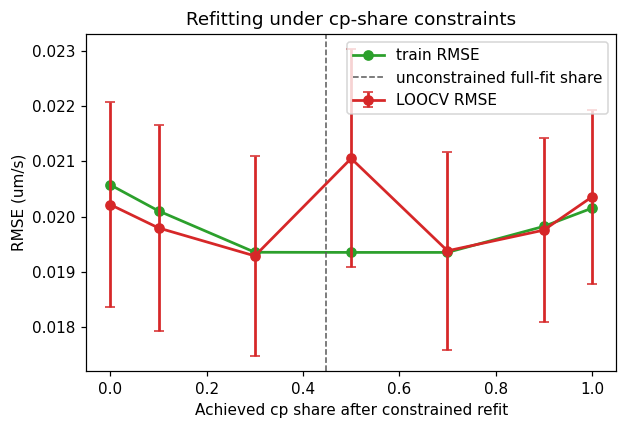

In [18]:
train_actual = np.array([row["actual_share"] for row in share_train_rows])
train_rmse = np.array([row["rmse"] for row in share_train_rows])
loocv_actual = np.array([row["mean_actual_share"] for row in share_loocv_rows])
loocv_rmse = np.array([row["rmse_mean"] for row in share_loocv_rows])
loocv_se = np.array([row["rmse_se"] for row in share_loocv_rows])

fig, ax = plt.subplots(figsize=(5.8, 4))
ax.plot(train_actual, train_rmse, marker="o", color="C2", linewidth=1.8, label="train RMSE")
ax.errorbar(
    loocv_actual,
    loocv_rmse,
    yerr=loocv_se,
    marker="o",
    color="C3",
    linewidth=1.8,
    capsize=3,
    label="LOOCV RMSE",
)
ax.axvline(fit_sep["cp_abs_fraction"], color="0.35", linestyle="--", linewidth=1.0, label="unconstrained full-fit share")
ax.set_xlabel("Achieved cp share after constrained refit")
ax.set_ylabel("RMSE (um/s)")
ax.set_title("Refitting under cp-share constraints")
ax.legend()
fig.tight_layout()
plt.show()

## Supplementary diagnostic: frozen-shape amplitude sweep

The pp-only and cp-only models above are full constrained refits
(the kernel shapes adapt to use only one feature block).  This
section asks a narrower question:

> If we keep the particular $f_{pp}(r)$ and $f_{cp}(r)$ shapes
> learned by the unconstrained full fit and only rescale their
> relative amplitudes, how does the separation prediction change?

This is **not** a constrained refit -- it holds the shapes fixed and
varies a single scalar weight.  Its purpose is to show how sensitive
the full-fit prediction is to the relative balance of its own learned
components.

**How to read the results:** A broad minimum means the full-fit shapes
tolerate a range of pp/cp balances.  The RMSE at extreme cp shares
(e.g. 90%) reflects how poorly those *particular shapes* transfer when
reweighted, not whether a 90%-cp model is impossible after refitting
(the cp-only model above already answers that).

In [19]:
pred_sep_pp = fit_sep["G"][:, :N_BASIS] @ fit_sep["full"]["theta"][:N_BASIS]
pred_sep_cp = fit_sep["G"][:, N_BASIS:] @ fit_sep["full"]["theta"][N_BASIS:]

scales = np.linspace(0.0, 20.0, 400)
frozen_cp_fractions = []
frozen_sep_rmses = []

for scale in scales:
    pred = pred_sep_pp + scale * pred_sep_cp
    frac = np.mean(
        np.abs(scale * pred_sep_cp)
        / np.where(
            np.abs(pred_sep_pp) + np.abs(scale * pred_sep_cp) > 0,
            np.abs(pred_sep_pp) + np.abs(scale * pred_sep_cp),
            1.0,
        )
    )
    rmse = np.sqrt(np.mean((fit_sep["Y"] - pred) ** 2))
    frozen_cp_fractions.append(frac)
    frozen_sep_rmses.append(rmse)

frozen_cp_fractions = np.array(frozen_cp_fractions)
frozen_sep_rmses = np.array(frozen_sep_rmses)

print("Frozen-shape amplitude sweep (separation observable)")
print(
    f"  baseline full-fit cp share = {fit_sep['cp_abs_fraction']:.3f}, "
    f"RMSE = {fit_sep['full']['rmse']:.5f} um/s"
)
for target in [0.1, 0.5, 0.9]:
    idx = int(np.argmin(np.abs(frozen_cp_fractions - target)))
    print(
        f"  target cp share {target:.1f}: "
        f"scale={scales[idx]:.2f}, "
        f"actual share={frozen_cp_fractions[idx]:.3f}, "
        f"RMSE={frozen_sep_rmses[idx]:.5f} um/s"
    )

Frozen-shape amplitude sweep (separation observable)
  baseline full-fit cp share = 0.448, RMSE = 0.01935 um/s


  target cp share 0.1: scale=0.05, actual share=0.080, RMSE=0.02267 um/s
  target cp share 0.5: scale=1.35, actual share=0.503, RMSE=0.01983 um/s
  target cp share 0.9: scale=20.00, actual share=0.884, RMSE=0.23624 um/s


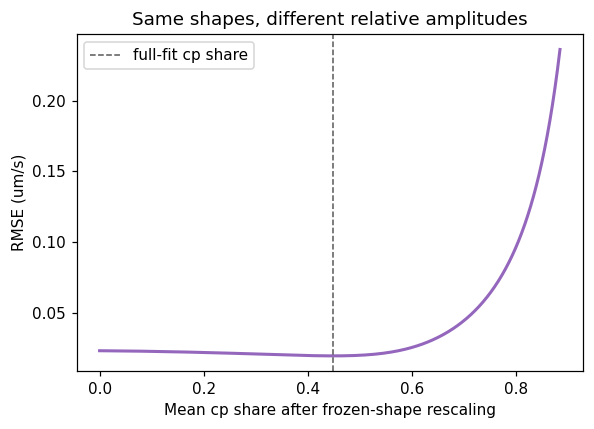

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(frozen_cp_fractions, frozen_sep_rmses, color="C4", linewidth=2)
ax.axvline(
    fit_sep["cp_abs_fraction"],
    color="0.35",
    linestyle="--",
    linewidth=1.0,
    label="full-fit cp share",
)
ax.set_xlabel("Mean cp share after frozen-shape rescaling")
ax.set_ylabel("RMSE (um/s)")
ax.set_title("Same shapes, different relative amplitudes")
ax.legend()
fig.tight_layout()
plt.show()

## Conclusions

### What we can say

1. There is a small lab-frame association between pole-midpoint motion
   and chromosome geometry: the pole midpoint drifts toward the
   chromosome cloud in the projection analysis.  In the restricted
   pp/cp regression family, this signal necessarily lives in the cp
   block because the pp term cannot move the pole COM by construction.

2. Mixing control and PRC1-depleted cells changes which lab-frame term
   carries the projection signal, which explains why earlier analyses
   seemed to give opposite results.

3. The "cp explains ~38-50% of pole force" number from the full 3D
   regression is a magnitude split of fitted vector components, not a
   biological force partition for any single observable.  In large part
   it is a structural consequence of the model family, because only the
   cp block can absorb common-mode pole translation.

4. For the observable that matters for interpolar force partition --
   **spindle separation rate** -- the pp-only and cp-only models are
   nearly tied in leave-one-cell-out cross-validation.  The data do
   not distinguish 0% cp from 100% cp.

5. The reason is overlap of the full design blocks, not just distance
   correlation.  For spindle separation, the axis-projected cp block is
   90% reconstructable from the pp block, while the cp block explains
   69% of pp-block variance.  So the directional chromosome geometry is
   itself strongly stage-locked over this early-prometaphase window.

6. Adding chromosome features to the 3D pole-velocity regression gives
   only a tiny incremental gain beyond pp (`dR2 = 0.0207`,
   `Cohen's f2 = 0.0223`).  That means chromosome geometry carries very
   little **separable** predictive information beyond pp distance over
   this window.  Because of block overlap, this is not proof of zero
   chromosome effect; it is a statement about identifiability.

7. A genuine constrained-refit sweep over target cp shares gives a
   broad, shallow LOOCV curve: on this grid, 10%-90% cp all fit within
   about `0.0011 um/s` of each other, comparable to the foldwise
   uncertainty.  That is stronger evidence of non-identifiability than
   the frozen-shape rescaling alone.

### What we cannot say

The trajectory regression alone does **not** identify whether the
chromosome share of interpolar separation is 10%, 50%, or 90%.
Nor does it fully orient causality for the small COM-drift signal:
that signal is consistent with chromosome back-reaction, but could
also reflect another omitted common-mode process correlated with
chromosome geometry.  So there is no clean positive causal evidence
here for chromosome-on-pole force.  Sharpening either question
requires an independent constraint:

- a perturbation that breaks the pp/cp collinearity
- a time window where chromosome-pole geometry and spindle opening
  decorrelate
- an independent physical argument -- but note that the trimmed
  control cells analyzed here have typical separation rates of only
  ~0.02 um/s, so any back-of-the-envelope force estimate should be
  compared against that scale directly